# Testing MG-cs2

In this notebook, I test a novel scenario in which the dark energy sound speed sources the braiding function $\alpha_B$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb

In [2]:
def get_camb_solution(alpha_K_0, cs2, omega_m, w0, wa, use_cs2):
    ombh2 = 0.0122
    h = 0.7
    omch2 = (omega_m - ombh2/h**2)*h**2
    cosmo = camb.set_params(
        H0=100*h, ombh2=ombh2, omch2=omch2, As=2.1e-9, ns=0.96, tau=0.06,
        num_nu_massless=3.044, omnuh2=0, WantTransfer=True, w=w0, wa=wa,
        dark_energy_model="fluid" if (1+w0)*(1+w0+wa) > 0 else "ppf",
        cs2_0=cs2, use_cs2=use_cs2, alpha_K_0=alpha_K_0, alpha_K_parametrization=1
    )
    cosmo.set_matter_power(redshifts=(0,), kmax=3)
    results = camb.get_background(cosmo)
    cl_tt = results.get_cmb_power_spectra(cosmo, CMB_unit="muK")["total"][:, 0]
    kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints=200)
    log_a = results.Params.log_a
    alpha_B = results.Params.alpha_B
    mu = results.Params.mu
    return log_a*np.log10(np.e), alpha_B, mu, kh, z, pk, cl_tt

Text(0, 0.5, '$C_\\ell^{TT}$')

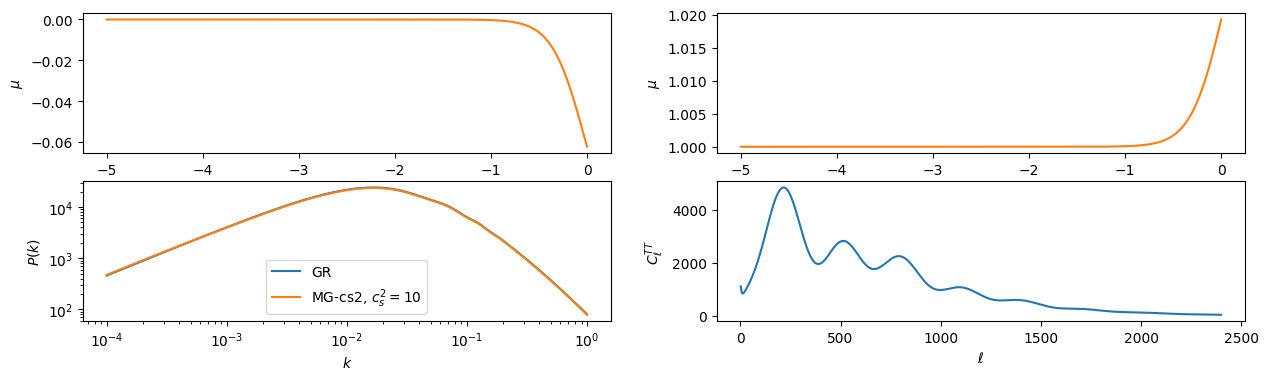

In [3]:
log_a, alpha_B, mu, kh, z, pk_mg, cl_tt_mg = get_camb_solution(alpha_K_0=1e-1, cs2=1, omega_m=0.3, w0=-0.9, wa=0, use_cs2=True)
_, _, _, kh, z, pk_gr, cl_tt_gr            = get_camb_solution(alpha_K_0=1e-1, cs2=1, omega_m=0.3, w0=-0.9, wa=0, use_cs2=False)
ell = np.arange(len(cl_tt_gr))

fig, axs = plt.subplots(2, 2, figsize=(15, 4))

axs[0,0].plot(log_a, alpha_B, color="tab:orange")
axs[0,0].set_xlabel("$\\log(a)$")
axs[0,0].set_ylabel("$\\mu$")

axs[0,1].plot(log_a, mu, color="tab:orange")
axs[0,1].set_xlabel("$\\log(a)$")
axs[0,1].set_ylabel("$\\mu$")

axs[1,0].loglog(kh, pk_gr[0], label="GR")
axs[1,0].loglog(kh, pk_mg[0], label="MG-cs2, $c_s^2 = 10$")
axs[1,0].set_xlabel("$k$")
axs[1,0].set_ylabel("$P(k)$")
axs[1,0].legend()

axs[1,1].plot(ell[2:], cl_tt_gr[2:])
axs[1,1].plot(ell[2:], cl_tt_mg[2:])
axs[1,1].set_xlabel("$\\ell$")
axs[1,1].set_ylabel("$C_\\ell^{TT}$")

In [4]:
np.array(alpha_B)

array([ 0.00000000e+00, -1.28461457e-17, -1.28461457e-17, -2.56922914e-17,
       -6.42307284e-17, -1.15615311e-16, -2.18384477e-16, -2.95461351e-16,
       -3.98230516e-16, -5.13845828e-16, -6.80845721e-16, -9.24922490e-16,
       -1.22038384e-15, -1.56722977e-15, -1.96546029e-15, -2.42792154e-15,
       -3.03169038e-15, -3.78961298e-15, -4.79161234e-15, -5.96061160e-15,
       -7.33514919e-15, -9.13360958e-15, -1.13174544e-14, -1.40151449e-14,
       -1.73808351e-14, -2.14916017e-14, -2.65272908e-14, -3.27833638e-14,
       -4.04268205e-14, -4.97788145e-14, -6.12375765e-14, -7.53554906e-14,
       -9.26977873e-14, -1.14009543e-13, -1.40112911e-13, -1.72099814e-13,
       -2.11254866e-13, -2.59183835e-13, -3.17839337e-13, -3.89585060e-13,
       -4.77170082e-13, -5.84127091e-13, -7.14618239e-13, -8.73807676e-13,
       -1.06778448e-12, -1.30403794e-12, -1.59150899e-12, -1.94116823e-12,
       -2.36608019e-12, -2.88199425e-12, -3.50793554e-12, -4.26682160e-12,
       -5.18615601e-12, -